In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
# Example dataset (replace with your file or download from WHO/Johns Hopkins)
df = pd.read_csv("Downloads/covid_19_data.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (9, 5)
  ObservationDate Country/Region  Confirmed  Deaths  Recovered
0      2020-03-01             US         30       1          0
1      2020-03-01          India          3       0          0
2      2020-03-01          Italy       1700      34         80
3      2020-03-02             US         50       2          5
4      2020-03-02          India          6       0          1


In [3]:
# Convert dates
df["ObservationDate"] = pd.to_datetime(df["ObservationDate"])

# Group by country & date
df_grouped = df.groupby(["Country/Region", "ObservationDate"]).sum().reset_index()

# Check missing values
print(df_grouped.isnull().sum())


Country/Region     0
ObservationDate    0
Confirmed          0
Deaths             0
Recovered          0
dtype: int64


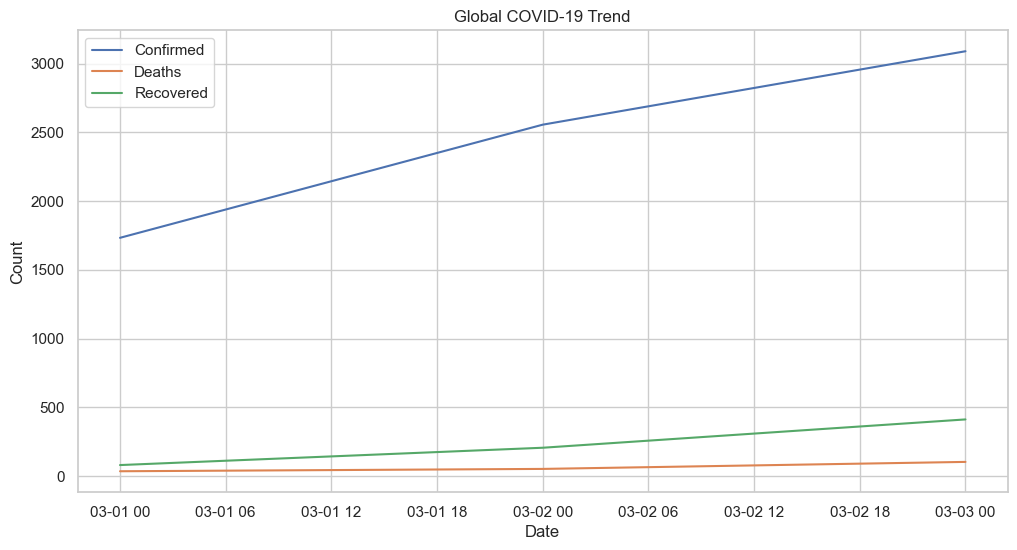

In [4]:
global_trend = df_grouped.groupby("ObservationDate")[["Confirmed", "Deaths", "Recovered"]].sum()

plt.figure(figsize=(12,6))
plt.plot(global_trend.index, global_trend["Confirmed"], label="Confirmed")
plt.plot(global_trend.index, global_trend["Deaths"], label="Deaths")
plt.plot(global_trend.index, global_trend["Recovered"], label="Recovered")
plt.title("Global COVID-19 Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.show()


/var/folders/z7/fmtdly0n56d_b1hqwv6wbgr40000gn/T/ipykernel_8623/2889974140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="Reds_r")


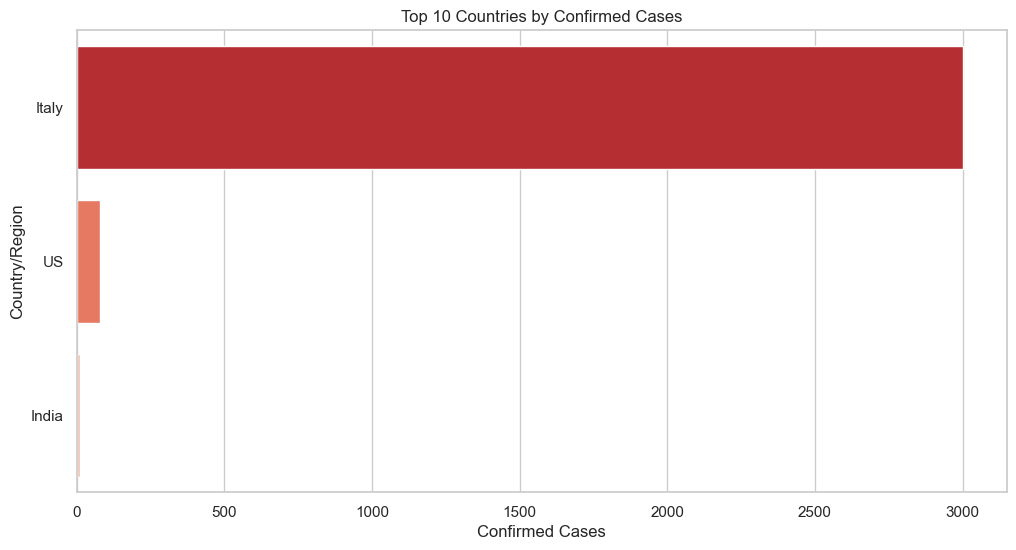

In [5]:
latest = df_grouped[df_grouped["ObservationDate"] == df_grouped["ObservationDate"].max()]
top10 = latest.groupby("Country/Region")["Confirmed"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top10.values, y=top10.index, palette="Reds_r")
plt.title("Top 10 Countries by Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.show()


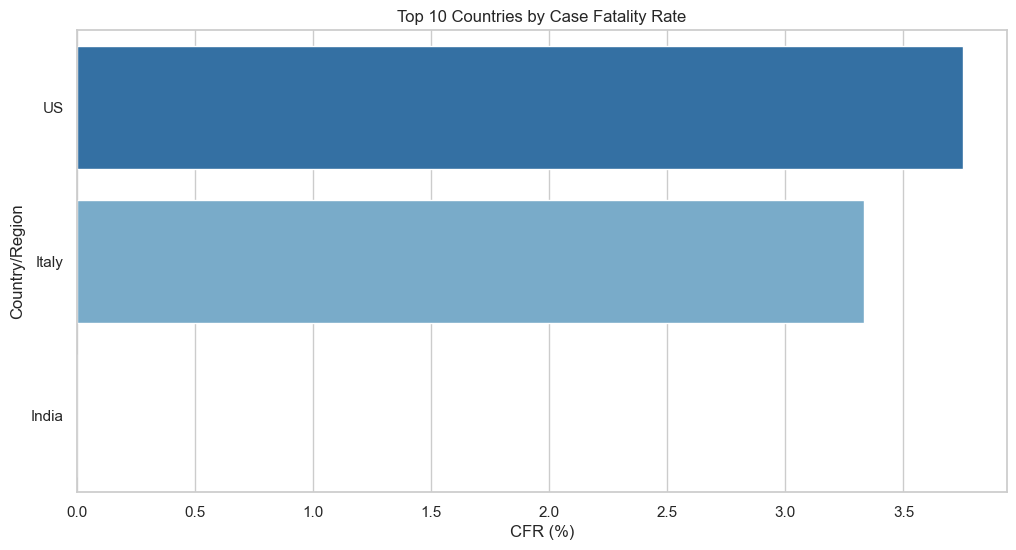

In [9]:
latest = latest.copy()
latest["CFR"] = (latest["Deaths"] / latest["Confirmed"]) * 100
cfr_top10 = latest.groupby("Country/Region")["CFR"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=cfr_top10.values, y=cfr_top10.index, hue=cfr_top10.index, palette="Blues_r", dodge=False, legend=False)
plt.title("Top 10 Countries by Case Fatality Rate")
plt.xlabel("CFR (%)")
plt.show()


In [7]:
df_grouped.to_csv("covid19_cleaned.csv", index=False)
print("✔ Cleaned dataset saved as covid19_cleaned.csv")

✔ Cleaned dataset saved as covid19_cleaned.csv
